# CatBoost Leaf Embeddings — Interactive Walkthrough

This notebook walks through the leaf-embedding soft-target algorithm one step at a time.

**The core idea in one sentence:** train a heavily regularised CatBoost as a *feature extractor*, read off which leaf each sample lands in across all trees (a learned embedding), compute Hamming distances in that space, and use an RBF kernel to diffuse binary labels into smooth soft targets.

Each section below introduces one conceptual step, runs the code, and shows the intermediate output so you can inspect what's happening before moving on.

In [1]:
import sys
from pathlib import Path
from rich import print

import matplotlib.pyplot as plt
# dark mode
plt.style.use("dark_background")
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, pairwise_distances

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

# make ml_elements importable from the notebook
sys.path.insert(0, str(Path.cwd().parent.parent))
from ml_elements.dgp import GaussianBinaryDGP

from catboost import CatBoostClassifier, CatBoostRegressor
from umap import UMAP

## Parameters

Edit this cell freely — every downstream cell reads from these variables.

In [47]:
SEED     = 42
P_POS    = 0.01  # fraction of positives in the data
N_TRAIN  = 5_000
N_TEST   = 20_000

# Feature signal strengths (higher = more separating)
FEATURE_INFO = {"x1": 0.7, "x2": 0.2, "x3": 0.4, "x4": 0.00, "x5": 0.00}

# Extractor: try heavy_reg first, then swap to light_reg in Part 10
EXTRACTOR_CFG = dict(depth=3, iterations=100, l2_leaf_reg=10, random_strength=10)
# EXTRACTOR_CFG = dict(depth=4, iterations=200, l2_leaf_reg=1, random_strength=1)  # light_reg

SIGMA = 0.5   # RBF bandwidth (fraction of trees that must differ)

---
## Part 1 — Data

We use `GaussianBinaryDGP`: each feature `x_j` is drawn from N(0, 1) for negatives and N(info_j, 1) for positives.
The `info` value is the mean shift in standard-deviation units — a clean signal-strength knob.

- `x1` (info=1.2): strong signal
- `x2` (info=0.8): moderate
- `x3` (info=0.4): weak
- `x4`, `x5`: near-noise

Only 10% of samples are positive — a realistic imbalance for many real problems.

In [48]:
dgp = GaussianBinaryDGP(p_pos=P_POS, info=FEATURE_INFO, sigma=1.0)

df_train = dgp.sample(n=N_TRAIN, seed=SEED)
df_test  = dgp.sample(n=N_TEST,  seed=SEED + 1_000)

y_train = df_train["y"].values
X_train = df_train.drop(columns="y").values
y_test  = df_test["y"].values
X_test  = df_test.drop(columns="y").values

feat_names = [c for c in df_train.columns if c != "y"]

print(f"Train: {N_TRAIN} rows, {y_train.sum()} positives ({100*y_train.mean():.1f}%)")
print(f"Test:  {N_TEST} rows,  {y_test.sum()} positives ({100*y_test.mean():.1f}%)")
df_train.head()

Train: 5000 rows, 60 positives (1.2%)

Test:  20000 rows,  171 positives (0.9%)

,y,x1,x2,x3,x4,x5
0,0,-1.098925,1.508077,-0.932890,0.541411,-0.521734
1,0,-0.541314,2.057802,-0.054155,-1.406480,0.016522
2,0,0.272001,0.234590,-0.378656,-0.838861,0.670770
3,0,-0.628320,-0.638429,0.819891,-0.430270,0.845136
4,0,-0.278366,-0.221640,0.847922,0.786850,0.318315


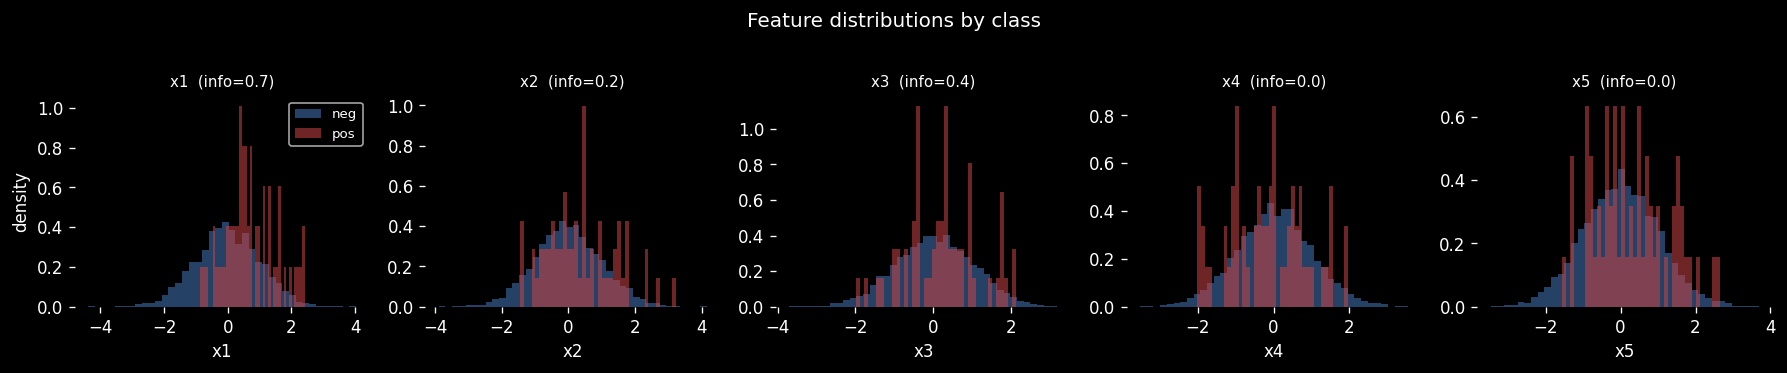

In [49]:
fig, axes = plt.subplots(1, len(feat_names), figsize=(3 * len(feat_names), 3), sharey=False)
for ax, feat in zip(axes, feat_names):
    neg_vals = df_train.loc[df_train["y"] == 0, feat]
    pos_vals = df_train.loc[df_train["y"] == 1, feat]
    ax.hist(neg_vals, bins=40, alpha=0.55, color="#4477bb", density=True, label="neg")
    ax.hist(pos_vals, bins=40, alpha=0.55, color="#cc4444", density=True, label="pos")
    ax.set_title(f"{feat}  (info={FEATURE_INFO[feat]})", fontsize=9)
    ax.set_xlabel(feat); ax.set_ylabel("density" if ax is axes[0] else "")
    if ax is axes[0]: ax.legend(fontsize=8)
    for s in ax.spines.values():
        s.set_visible(False)
fig.suptitle("Feature distributions by class", y=1.02)
fig.tight_layout()

---
## Part 2 — Feature extractor

We train a CatBoost classifier, but **not to use its predictions**.
We use it as a *feature extractor* — a device that learns which regions of the input space are
associated with positive outcomes.

Heavy regularisation (`l2_leaf_reg=100`, `depth=3`) is intentional:
only patterns supported by many samples will create distinct leaves.
This matches the goal of not learning patterns that are too weak for the available data.

A shallow, heavily regularised CatBoost becomes a robust partitioner of the space.

In [50]:
extractor = CatBoostClassifier(
    **EXTRACTOR_CFG,
    loss_function="Logloss",
    verbose=False,
    allow_writing_files=False,
    random_seed=SEED,
)
extractor.fit(X_train, y_train)

extractor_ap = average_precision_score(
    y_train, extractor.predict_proba(X_train)[:, 1]
)

print(f"Extractor trees:  {extractor.tree_count_}")
print(f"Extractor depth:  {EXTRACTOR_CFG['depth']}")
print(f"Train AP (extractor itself): {extractor_ap:.4f}  ← we only care that it learned *something*")
# base rate
print(f"Base rate: {y_train.mean():.4f}")
# lift
print(f"Lift: {extractor_ap / y_train.mean():.2e}")

Extractor trees:  100

Extractor depth:  3

Train AP (extractor itself): 0.0433  ← we only care that it learned *something*

Base rate: 0.0120

Lift: 3.61e+00

---
## Part 3 — Leaf embeddings

`model.calc_leaf_indexes(X)` returns an integer array of shape `(n_samples, n_trees)`.
Each entry is the index of the leaf that sample landed in for that tree.

This is a **learned embedding**: the model has partitioned the feature space, and the
leaf ID tells you which cell of that partition each sample belongs to.
Two samples sharing many leaf IDs were routed through the same decision paths — they look
similar to CatBoost's learned representation.

In [51]:
leaf_emb = extractor.calc_leaf_indexes(X_train).astype(float)  # (n_train, n_trees)

print(f"Embedding shape: {leaf_emb.shape}  → ({N_TRAIN} samples, {extractor.tree_count_} trees)")
print(f"Leaf ID range:   {int(leaf_emb.min())} – {int(leaf_emb.max())}")

# Show as a DataFrame — each column is one tree, each value is a leaf index
col_names = [f"tree_{i}" for i in range(extractor.tree_count_)]
pd.DataFrame(leaf_emb[:5].astype(int), columns=col_names)

Embedding shape: (5000, 100)  → (5000 samples, 100 trees)

Leaf ID range:   0 – 7

,tree_0,tree_1,tree_2,tree_3,tree_4,tree_5,tree_6,tree_7,tree_8,tree_9,...,tree_90,tree_91,tree_92,tree_93,tree_94,tree_95,tree_96,tree_97,tree_98,tree_99
0,2,6,3,3,2,4,3,5,4,0,...,2,4,5,5,0,4,4,1,4,3
1,2,3,5,7,2,4,3,7,6,1,...,7,4,4,5,1,6,5,7,2,2
2,2,2,1,3,5,4,2,7,7,7,...,6,3,4,7,1,6,4,5,3,2
3,0,3,0,7,1,4,2,5,6,7,...,6,3,4,6,1,6,5,5,3,2
4,2,7,3,7,5,4,6,7,6,7,...,6,1,5,6,1,6,5,5,6,3


In [52]:
# Peek: compare leaf vectors for two positives and one negative
rng = np.random.default_rng(SEED)
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]

p0, p1 = rng.choice(pos_idx, 2, replace=False)
n0     = rng.choice(neg_idx, 1)[0]

def shared_leaves(a, b):
    return int((a == b).sum()), len(a)

sh_pp, total = shared_leaves(leaf_emb[p0], leaf_emb[p1])
sh_pn, _     = shared_leaves(leaf_emb[p0], leaf_emb[n0])

print(f"Positive #{p0} vs positive #{p1}:  shared {sh_pp}/{total} leaves  "
      f"→ Hamming = {1 - sh_pp/total:.3f}")
print(f"Positive #{p0} vs negative #{n0}:  shared {sh_pn}/{total} leaves  "
      f"→ Hamming = {1 - sh_pn/total:.3f}")
print("\nTwo positives typically share more leaves than a pos–neg pair.")

Positive #667 vs positive #3988:  shared 17/100 leaves  → Hamming = 0.830

Positive #667 vs negative #2196:  shared 24/100 leaves  → Hamming = 0.760

Two positives typically share more leaves than a pos–neg pair.

---
## Part 4 — Hamming distance

Hamming distance between two leaf vectors = fraction of trees where they land in **different** leaves.
It lives in [0, 1].

Why not Euclidean?
Leaf IDs are **categorical** — leaf 5 is not "closer" to leaf 6 than to leaf 12.
Hamming treats each tree as a binary question: "did they end up in the same cell?"

Distance matrix shape: (5000, 5000)

D range: [0.0000, 1.0000]  mean: 0.6656

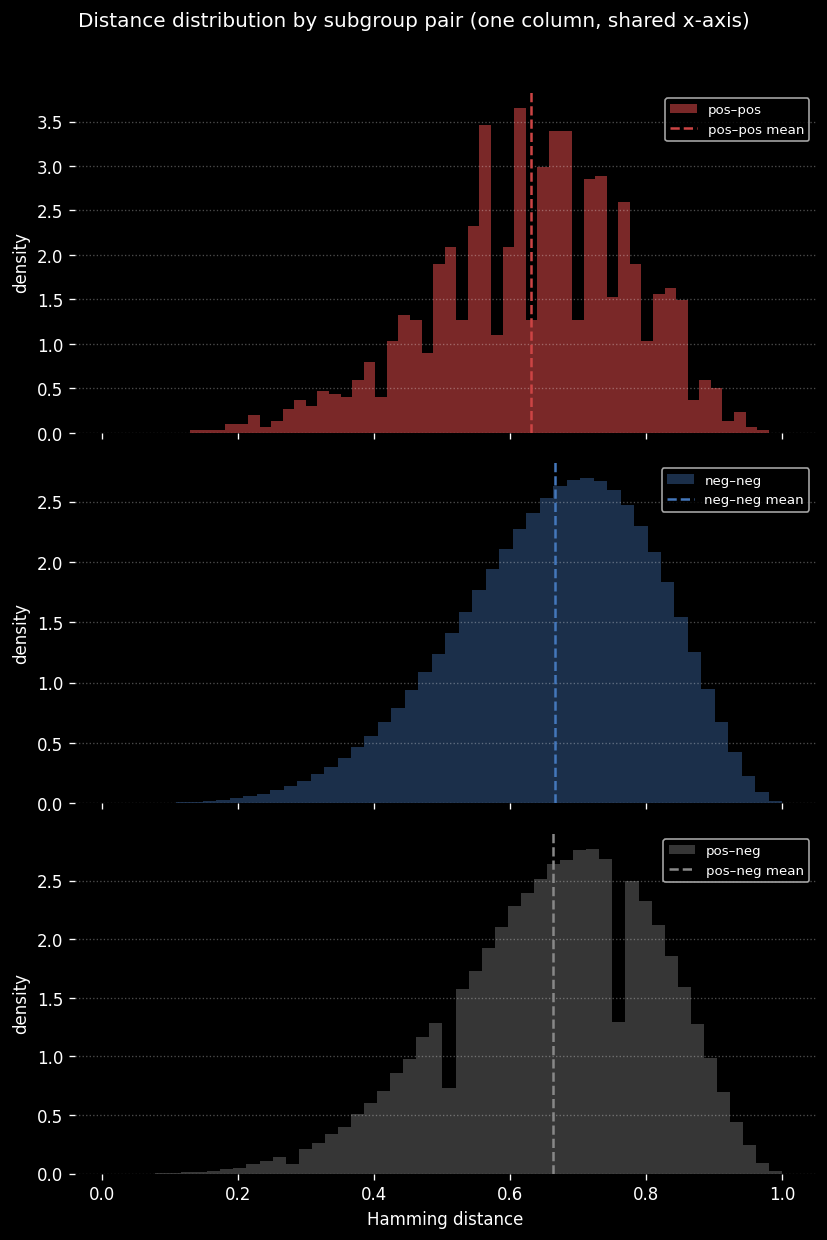

In [53]:
D = pairwise_distances(leaf_emb, metric="hamming")  # (n_train, n_train), values in [0, 1]

print(f"Distance matrix shape: {D.shape}")
print(f"D range: [{D.min():.4f}, {D.max():.4f}]  mean: {D.mean():.4f}")

# Distance distribution by subgroup pair
pp_mask = np.outer(y_train == 1, y_train == 1)
nn_mask = np.outer(y_train == 0, y_train == 0)
pn_mask = np.outer(y_train == 1, y_train == 0)
np.fill_diagonal(pp_mask, False); np.fill_diagonal(nn_mask, False)

# Gather data for each group
data = [
    (D[pp_mask], "pos–pos", "#cc4444", 0.6),
    (D[nn_mask], "neg–neg", "#4477bb", 0.4),
    (D[pn_mask], "pos–neg", "#888888", 0.4)
]

fig, axes = plt.subplots(len(data), 1, figsize=(7, 3.5 * len(data)), sharex=True)
if len(data) == 1:
    axes = [axes]

for ax, (vals, label, color, alpha) in zip(axes, data):
    ax.hist(vals, bins=50, alpha=alpha, color=color, density=True, label=label)
    ax.axvline(vals.mean(), color=color, linestyle="--", linewidth=1.5, label=f"{label} mean")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3, linestyle=":")
    for s in ax.spines.values():
        s.set_visible(False)

axes[-1].set_xlabel("Hamming distance")
fig.suptitle("Distance distribution by subgroup pair (one column, shared x-axis)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])

---
## Part 5 — RBF kernel

$$K(i,j) = \exp\!\left(-\frac{d_{\text{Hamming}}(i,j)^2}{2\sigma^2}\right)$$

$\sigma$ is the neighbourhood radius in Hamming units.

- $\sigma = 0.10$: two samples sharing ≥90% of leaves get weight ≈ 0.6
- Small $\sigma$: tight, high-confidence neighbourhoods
- Large $\sigma$: broad diffusion, eventually collapses to base rate

Kernel  min=0.1353  max=1.0000  mean=0.4232

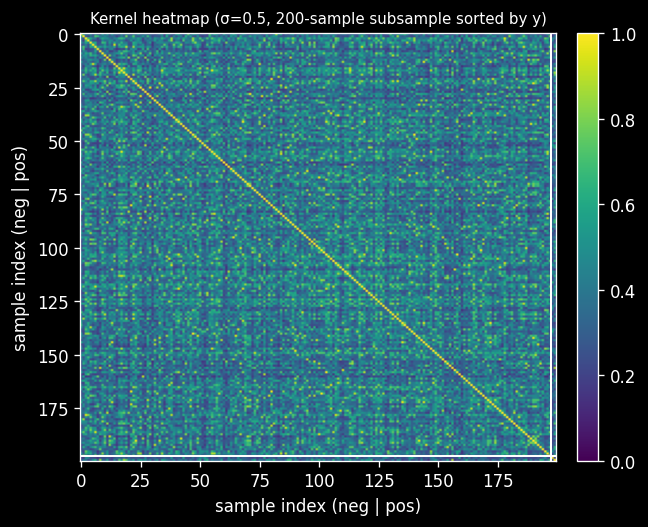

In [54]:
K = np.exp(-(D ** 2) / (2.0 * SIGMA ** 2))

print(f"Kernel  min={K.min():.4f}  max={K.max():.4f}  mean={K.mean():.4f}")

# Heatmap — 200-sample subsample sorted by y
rng2 = np.random.default_rng(SEED)
idx  = rng2.choice(len(y_train), size=200, replace=False)
order = np.argsort(y_train[idx])
sub   = idx[order]
K_sub = K[np.ix_(sub, sub)]
n_neg_sub = (y_train[sub] == 0).sum()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(K_sub, aspect="auto", cmap="viridis", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.axhline(n_neg_sub - 0.5, color="white", linewidth=1.2)
ax.axvline(n_neg_sub - 0.5, color="white", linewidth=1.2)
ax.set_title(f"Kernel heatmap (σ={SIGMA}, 200-sample subsample sorted by y)", fontsize=9)
ax.set_xlabel("sample index (neg | pos)")
ax.set_ylabel("sample index (neg | pos)")
plt.tight_layout()

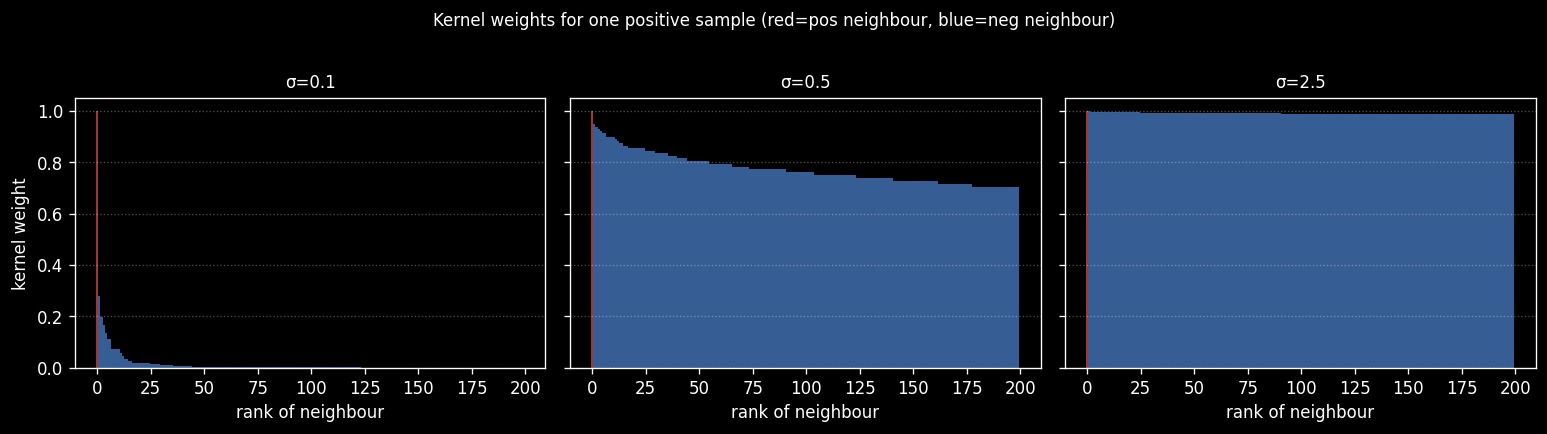

In [55]:
# Sigma sensitivity: show how the neighbourhood of one positive sample changes
anchor = pos_idx[0]
sigmas_demo = [SIGMA * 0.2, SIGMA, SIGMA * 5]
labels_demo = [f"σ={s:.3f}".rstrip("0").rstrip(".") for s in sigmas_demo]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, sig, lbl in zip(axes, sigmas_demo, labels_demo):
    K_demo = np.exp(-(D[anchor] ** 2) / (2 * sig ** 2))
    sorted_w = np.sort(K_demo)[::-1][:200]   # top-200 neighbours
    colors = np.where(y_train[np.argsort(K_demo)[::-1][:200]] == 1, "#cc4444", "#4477bb")
    ax.bar(range(200), sorted_w, color=colors, width=1.0, alpha=0.8)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel("rank of neighbour")
    if ax is axes[0]: ax.set_ylabel("kernel weight")
    ax.grid(axis="y", alpha=0.3, linestyle=":")
fig.suptitle(
    f"Kernel weights for one positive sample (red=pos neighbour, blue=neg neighbour)",
    fontsize=10, y=1.02
)
plt.tight_layout()

---
## Part 6 — Soft targets

For each sample $i$ we aggregate kernel weights over positives and negatives:

$$\alpha_i = 1 + \sum_{j:\,y_j=1} K(i,j) \qquad \beta_i = 1 + \sum_{j:\,y_j=0} K(i,j)$$

$$\hat{y}_i^{\text{soft}} = \frac{\alpha_i}{\alpha_i + \beta_i}$$

This is the mean of a Beta posterior with a uniform (Laplace) prior.
The `+1` terms prevent division by zero and encode "I know nothing" as the starting point.

A sample deep inside a positive cluster gets a high $\alpha$ and a low $\beta$ → $\hat{y}$ near 1.  
A sample far from all positives gets both $\alpha$ and $\beta$ driven by the base rate → $\hat{y}$ near `p_pos`.

In [56]:
n = len(y_train)
if K.shape != (n, n):
    if leaf_emb.shape[0] != n:
        raise ValueError(
            f"Kernel {K.shape} and labels ({n},) disagree — "
            "re-run from Part 1 (data) through Part 3 (leaf embeddings)."
        )
    D = pairwise_distances(leaf_emb, metric="hamming")
    K = np.exp(-(D ** 2) / (2.0 * SIGMA ** 2))

pos_mask = y_train == 1
neg_mask = y_train == 0

global_y_mean = y_train.mean()
prior_y_mean = global_y_mean
prior_strength = 1 / global_y_mean

y_f = y_train.astype(np.float64)
alpha = prior_strength * prior_y_mean + K @ y_f
beta = prior_strength + K @ (1.0 - y_f)
y_soft = alpha / (alpha + beta)/prior_y_mean

mean_pos = y_soft[pos_mask].mean()
mean_neg = y_soft[neg_mask].mean()

print(f"y_soft mean for positives : {mean_pos:.4f}")
print(f"y_soft mean for negatives : {mean_neg:.4f}")
print(f"Separation (pos − neg)    : {mean_pos - mean_neg:.4f}")

y_soft mean for positives : 1.0987

y_soft mean for negatives : 1.0033

Separation (pos − neg)    : 0.0955

In [57]:
# Individual examples: 5 positives + 5 negatives
rng3     = np.random.default_rng(SEED + 1)
sample_p = rng3.choice(np.where(pos_mask)[0], 5, replace=False)
sample_n = rng3.choice(np.where(neg_mask)[0], 5, replace=False)
sample   = np.concatenate([sample_p, sample_n])

pd.DataFrame({
    "sample_idx"      : sample,
    "y_hard"          : y_train[sample],
    "y_soft"          : y_soft[sample].round(4),
    "Σ K (pos nbrs)"  : K[sample][:, pos_mask].sum(axis=1).round(2),
    "Σ K (neg nbrs)"  : K[sample][:, neg_mask].sum(axis=1).round(2),
})

,sample_idx,y_hard,y_soft,Σ K (pos nbrs),Σ K (neg nbrs)
0,409,1,1.0812,23.03,1745.05
1,2717,1,1.0389,31.26,2472.38
2,1861,1,1.0661,19.76,1518.53
3,2903,1,1.0710,25.15,1925.22
4,2210,1,1.0621,26.79,2069.18
5,4230,0,0.9673,28.26,2407.75
6,1122,0,1.0270,27.67,2214.11
7,2937,0,1.0569,27.21,2112.48
8,3758,0,1.1949,32.55,2222.85
9,4821,0,0.8275,19.96,2006.41


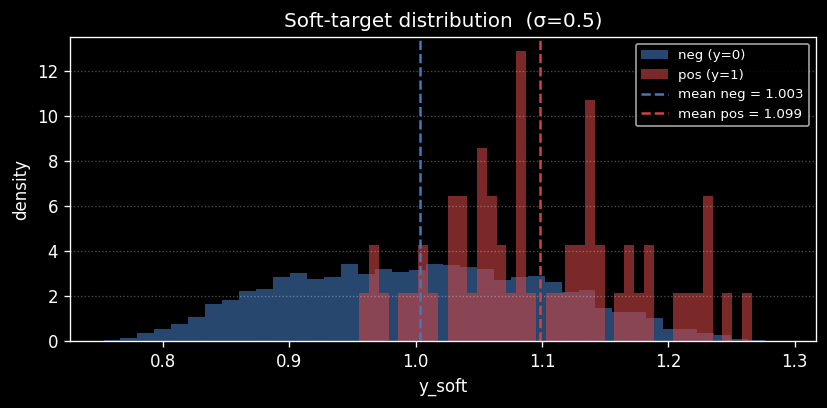

In [58]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(y_soft[neg_mask], bins=40, alpha=0.6, color="#4477bb", density=True, label="neg (y=0)")
ax.hist(y_soft[pos_mask], bins=40, alpha=0.6, color="#cc4444", density=True, label="pos (y=1)")
ax.axvline(mean_neg, color="#4477bb", linestyle="--", linewidth=1.5, label=f"mean neg = {mean_neg:.3f}")
ax.axvline(mean_pos, color="#cc4444", linestyle="--", linewidth=1.5, label=f"mean pos = {mean_pos:.3f}")
ax.set_xlabel("y_soft"); ax.set_ylabel("density")
ax.set_title(f"Soft-target distribution  (σ={SIGMA})")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3, linestyle=":")
plt.tight_layout()

---
## Part 7 — UMAP projection

UMAP with `metric="hamming"` projects the leaf-embedding space into 2D while
preserving the same Hamming distances we used for the kernel.

**Left panel** — binary hard labels. The positives (red) are sparse and scattered.

**Right panel** — continuous soft targets on a coolwarm scale.
Look for smooth hills of red around the positive clusters: that is the kernel diffusion at work.
Isolated positives near dense negative regions should get a lower soft target than positives
surrounded by other positives.

In [59]:
print("Fitting UMAP (may take ~15 s) …")
Z = UMAP(n_components=2, metric="hamming", random_state=SEED, n_neighbors=50, min_dist=0.05).fit_transform(leaf_emb)
print(f"UMAP output shape: {Z.shape}")


Fitting UMAP (may take ~15 s) …

/Users/poincare/micromamba/envs/intel/lib/python3.13/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/Users/poincare/micromamba/envs/intel/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (5000, 2)

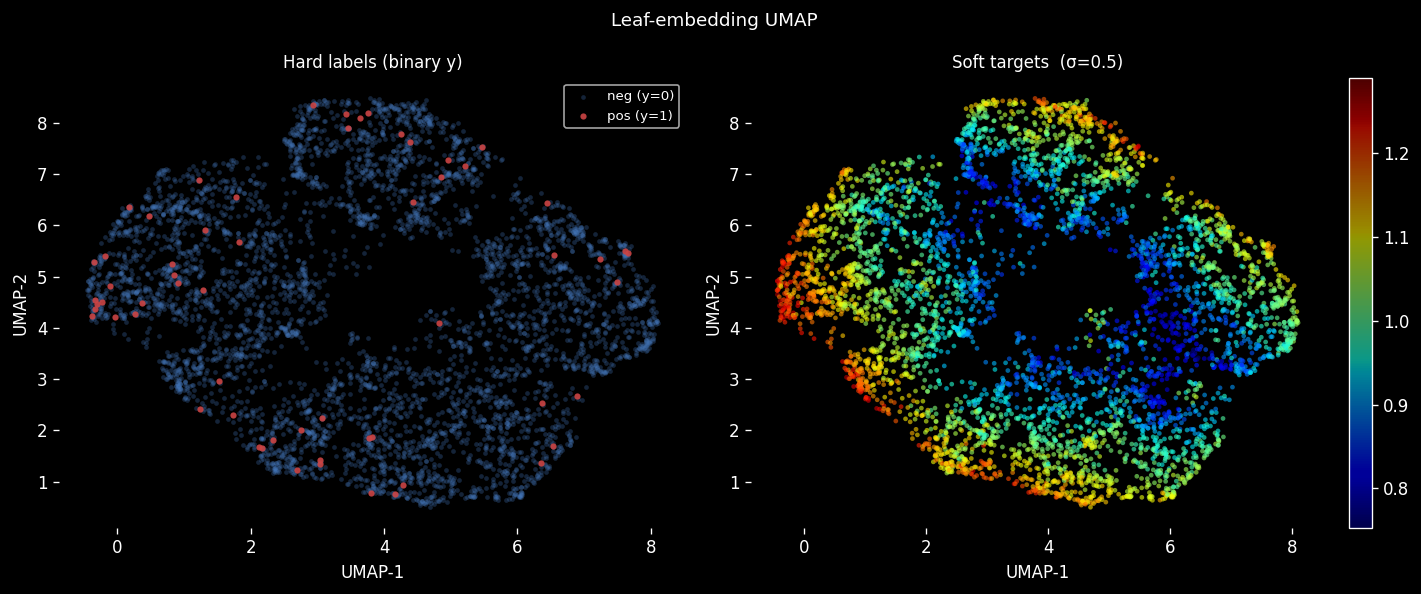

In [60]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left — hard labels: negatives first so positives sit on top
ax1.scatter(Z[neg_mask, 0], Z[neg_mask, 1], c="#4477bb", s=8, alpha=0.3, linewidths=0, label="neg (y=0)")
ax1.scatter(Z[pos_mask, 0], Z[pos_mask, 1], c="#cc4444", s=14, alpha=0.9, linewidths=0, label="pos (y=1)")
ax1.set_title("Hard labels (binary y)", fontsize=10)
ax1.set_xlabel("UMAP-1"); ax1.set_ylabel("UMAP-2")
ax1.legend(fontsize=8)
for s in ax1.spines.values():
    s.set_visible(False)

# Right — soft targets
sc = ax2.scatter(Z[:, 0], Z[:, 1], c=y_soft, cmap="jet", s=8, alpha=0.6, linewidths=0)
fig.colorbar(sc, ax=ax2, fraction=0.046, pad=0.04)
ax2.set_title(f"Soft targets  (σ={SIGMA})", fontsize=10)
ax2.set_xlabel("UMAP-1"); ax2.set_ylabel("UMAP-2")
for s in ax2.spines.values():
    s.set_visible(False)

fig.suptitle("Leaf-embedding UMAP", fontsize=11)
plt.tight_layout()

---
## Part 8 — Sigma sweep

How does sigma change the soft targets?

- Small σ → tight neighbourhoods → sharp soft targets → high pos/neg separation
- Large σ → broad diffusion → soft targets collapse toward the base rate `p_pos`

In [61]:
sigmas_sweep = [0.05, 0.10, 0.25, 0.50]
sweep_rows = []
soft_by_sigma = {}

global_y_mean = y_train.mean()
prior_y_mean = global_y_mean 
prior_strength = 1/global_y_mean

for sig in sigmas_sweep:
    K_s   = np.exp(-(D ** 2) / (2.0 * sig ** 2))
    a_s   = prior_strength*prior_y_mean + K_s[:, pos_mask].sum(axis=1)
    b_s   = prior_strength + K_s[:, neg_mask].sum(axis=1)
    ys    = a_s / (a_s + b_s)/prior_y_mean
    soft_by_sigma[sig] = ys
    sweep_rows.append({
        "sigma"           : sig,
        "mean y_soft pos" : round(ys[pos_mask].mean(), 4),
        "mean y_soft neg" : round(ys[neg_mask].mean(), 4),
        "separation"      : round(ys[pos_mask].mean() - ys[neg_mask].mean(), 4),
    })

pd.DataFrame(sweep_rows)

,sigma,mean y_soft pos,mean y_soft neg,separation
0,0.05,1.9495,0.9763,0.9731
1,0.10,1.9272,0.9815,0.9458
2,0.25,1.3926,1.0016,0.3910
3,0.50,1.0987,1.0033,0.0955


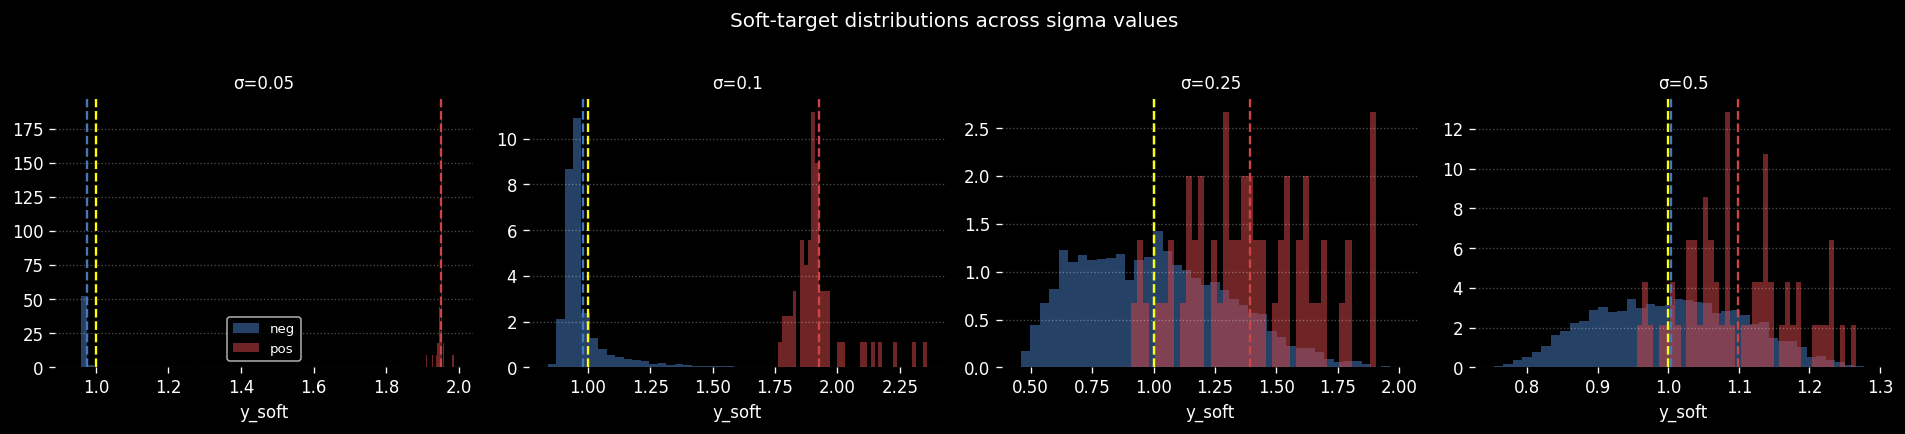

In [62]:
fig, axes = plt.subplots(1, len(sigmas_sweep), figsize=(4 * len(sigmas_sweep), 3.5), sharey=False)
for ax, sig in zip(axes, sigmas_sweep):
    ys = soft_by_sigma[sig]
    ax.hist(ys[neg_mask], bins=40, alpha=0.55, color="#4477bb", density=True, label="neg")
    ax.hist(ys[pos_mask], bins=40, alpha=0.55, color="#cc4444", density=True, label="pos")
    ax.axvline(ys[neg_mask].mean(), color="#4477bb", linestyle="--", linewidth=1.4)
    ax.axvline(ys[pos_mask].mean(), color="#cc4444", linestyle="--", linewidth=1.4)
    ax.set_title(f"σ={sig}", fontsize=10)
    ax.set_xlabel("y_soft")
    ax.grid(axis="y", alpha=0.3, linestyle=":")
    for s in ax.spines.values():
        s.set_visible(False)
    if ax is axes[0]: ax.legend(fontsize=8)
    ax.axvline(1, color="yellow", linestyle="--", linewidth=1.4)
fig.suptitle("Soft-target distributions across sigma values", y=1.02)
plt.tight_layout()

---
## Part 9 — Does it help a downstream model?

The soft targets are interesting on their own, but the practical question is:
does training a second CatBoost on `y_soft` produce better Average Precision on a held-out test set
than training the same architecture on the hard binary labels?

- Hard: `CatBoostClassifier` with `Logloss`
- Soft: `CatBoostRegressor` with `RMSE` — the soft targets are in (0,1), so regression is natural;
  the output scores are used directly for AP ranking

In [63]:
_shared_kw = dict(iterations=200, depth=4, learning_rate=0.06,
                  verbose=False, allow_writing_files=False, random_seed=SEED)

m_hard = CatBoostClassifier(**_shared_kw, loss_function="Logloss")
m_hard.fit(X_train, y_train)
ap_hard = average_precision_score(y_test, m_hard.predict_proba(X_test)[:, 1])

m_soft = CatBoostRegressor(**_shared_kw, loss_function="RMSE")
m_soft.fit(X_train, y_soft)          # y_soft computed with current SIGMA
ap_soft = average_precision_score(y_test, m_soft.predict(X_test))

print(f"AP (hard y,   σ={SIGMA}): {ap_hard:.4f}")
print(f"AP (soft y_soft, σ={SIGMA}): {ap_soft:.4f}   Δ = {ap_soft - ap_hard:+.4f}")

AP (hard y,   σ=0.5): 0.0179

AP (soft y_soft, σ=0.5): 0.0214   Δ = +0.0035

In [64]:
# Sweep AP over all sigmas
ap_rows = []
for sig in sigmas_sweep:
    ys = soft_by_sigma[sig]
    m  = CatBoostRegressor(**_shared_kw, loss_function="RMSE")
    m.fit(X_train, ys)
    ap_s = average_precision_score(y_test, m.predict(X_test))
    ap_rows.append({"sigma": sig, "AP hard": round(ap_hard, 4), "AP soft": round(ap_s, 4),
                    "delta": round(ap_s - ap_hard, 4)})

ap_df = pd.DataFrame(ap_rows)
print(ap_df.to_string(index=False))

sigma  AP hard  AP soft   delta
  0.05   0.0179   0.0153 -0.0025
  0.10   0.0179   0.0142 -0.0037
  0.25   0.0179   0.0180  0.0001
  0.50   0.0179   0.0214  0.0035

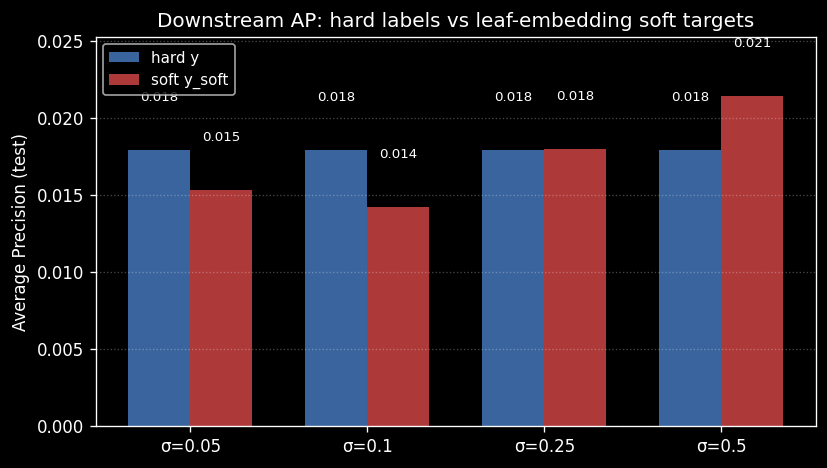

In [65]:
x  = np.arange(len(sigmas_sweep))
w  = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
bars_h = ax.bar(x - w/2, ap_df["AP hard"], w, label="hard y",       color="#4477bb", alpha=0.85)
bars_s = ax.bar(x + w/2, ap_df["AP soft"], w, label="soft y_soft",  color="#cc4444", alpha=0.85)
for bar in list(bars_h) + list(bars_s):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003, f"{h:.3f}",
            ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f"σ={s}" for s in sigmas_sweep])
ax.set_ylabel("Average Precision (test)")
ax.set_title("Downstream AP: hard labels vs leaf-embedding soft targets")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.28, linestyle=":")
ax.set_ylim(0, min(1.0, ap_df[["AP hard", "AP soft"]].values.max() * 1.18))
plt.tight_layout()

---
## Part 10 — Heavy vs light regularisation

The extractor's regularisation strength changes the embedding:

- **heavy_reg** (depth=3, l2=100): only robust, data-supported patterns create distinct leaves.
  The embedding is conservative.
- **light_reg** (depth=4, l2=1): CatBoost can fit noisier patterns, creating more fine-grained
  partitions. The embedding is more expressive but potentially noisier.

The cell below runs the full pipeline for both and compares separation and downstream AP.

In [66]:
configs = {
    "heavy_reg": dict(depth=3, iterations=100, l2_leaf_reg=100, random_strength=10),
    "light_reg": dict(depth=4, iterations=200, l2_leaf_reg=1,   random_strength=1),
}

comparison_rows = []
for cfg_name, cfg in configs.items():
    ext = CatBoostClassifier(**cfg, loss_function="Logloss",
                             verbose=False, allow_writing_files=False, random_seed=SEED)
    ext.fit(X_train, y_train)
    emb = ext.calc_leaf_indexes(X_train).astype(float)
    D_c = pairwise_distances(emb, metric="hamming")
    K_c = np.exp(-(D_c ** 2) / (2.0 * SIGMA ** 2))
    a_c = 1.0 + K_c[:, pos_mask].sum(axis=1)
    b_c = 1.0 + K_c[:, neg_mask].sum(axis=1)
    ys_c = a_c / (a_c + b_c)

    m_s = CatBoostRegressor(**_shared_kw, loss_function="RMSE")
    m_s.fit(X_train, ys_c)
    ap_s = average_precision_score(y_test, m_s.predict(X_test))

    comparison_rows.append({
        "config"          : cfg_name,
        "emb_dims"        : emb.shape[1],
        "mean y_soft pos" : round(ys_c[pos_mask].mean(), 4),
        "mean y_soft neg" : round(ys_c[neg_mask].mean(), 4),
        "separation"      : round(ys_c[pos_mask].mean() - ys_c[neg_mask].mean(), 4),
        "AP hard"         : round(ap_hard, 4),
        "AP soft"         : round(ap_s, 4),
        "delta AP"        : round(ap_s - ap_hard, 4),
    })

pd.DataFrame(comparison_rows)

,config,emb_dims,mean y_soft pos,mean y_soft neg,separation,AP hard,AP soft,delta AP
0,heavy_reg,100,0.0137,0.0125,0.0012,0.0179,0.0254,0.0075
1,light_reg,200,0.0131,0.0116,0.0014,0.0179,0.0200,0.0021


---
## Reflection

**What we built:**
1. A conservative CatBoost partitions the feature space into leaves — *robust* regions
2. Hamming distance in leaf space measures how similar two samples are *under the model's learned structure*
3. An RBF kernel turns distances into neighbourhood weights
4. A Beta-Binomial aggregation diffuses label information: each sample inherits a weighted average of the labels of its neighbours
5. The result is a smooth, continuous soft target that encodes uncertainty — isolated positives
   get pulled down toward the base rate; positives in positive clusters get pushed up toward 1

**What to try next:**
- Bring your own real dataset (swap in `RealDataDGP` from `ml_elements.dgp`)
- Change `SIGMA` in the parameters cell and re-run Parts 6–9 to see the effect
- Swap the extractor config in the parameters cell to `light_reg` and re-run from Part 2
- Try `EXTRACTOR_CFG` with `depth=2` for an even more conservative extractor